In [1]:
# %cd ~/repos/foo_cleaned

In [2]:
import os
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import util.functions as functions
import pybamm
import numpy as np
from tqdm import trange
#os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".20"

In [3]:
from models.FNO import CAPE_FNO2
from util.FNO_util import train_test_split, normalise_diffusion, preprocess_data, data_loader_pe, remove_padding
from training.scheduler import cosine_schedule_with_warmup
from util.plotting import create_plot_FNO_results, plot_losses

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
print("All devices:", jax.devices())
print("Default backend:", jax.default_backend())

All devices: [CudaDevice(id=0)]
Default backend: gpu


In [6]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)
parameter_name = "Prada2013"
params_bat = pybamm.ParameterValues(parameter_name)

C = params_bat["Nominal cell capacity [A.h]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
t_max = 3600

In [7]:
family = "GRF"
N_total = 33011
data = np.load(f"../data/{parameter_name}_{family}_{N_total}.npz")
random_seed = 42
test_ratio = 0.1

In [8]:
train_data, test_data = train_test_split(data, N_total=N_total, test_ratio=test_ratio, seed=random_seed)  # noqa: F405

In [9]:
train_I = np.array(train_data["current"])
test_I = np.array(test_data["current"])

### Anode data ###
train_cn_anode = np.array(train_data["cn_anode"])
test_cn_anode = np.array(test_data["cn_anode"])
train_c0_anode = np.array(train_data["c0_anode"])
test_c0_anode = np.array(test_data["c0_anode"])
train_D_anode = np.array(train_data["D_n"])
test_D_anode = np.array(test_data["D_n"])
# train_eps_anode = np.array(train_data["eps_n"])
# test_eps_anode = np.array(test_data["eps_n"])
# train_L_anode = np.array(train_data["L_n"])
# test_L_anode = np.array(test_data["L_n"])
train_R_anode = np.array(train_data["R_n"])
test_R_anode = np.array(test_data["R_n"])

# train_A = np.array(train_data["A"])
# test_A = np.array(test_data["A"])


###Cathode data ###
train_cn_cathode = np.array(train_data["cn_cathode"])
test_cn_cathode = np.array(test_data["cn_cathode"])
train_c0_cathode = np.array(train_data["c0_cathode"])
test_c0_cathode = np.array(test_data["c0_cathode"])
train_D_cathode = np.array(train_data["D_p"])
test_D_cathode = np.array(test_data["D_p"])
# train_eps_cathode = np.array(train_data["eps_p"])
# test_eps_cathode = np.array(test_data["eps_p"])
# train_L_cathode = np.array(train_data["L_p"])
# test_L_cathode = np.array(test_data["L_p"])
train_R_cathode = np.array(train_data["R_p"])
test_R_cathode = np.array(test_data["R_p"])

In [10]:
F = pybamm.constants.F  # As/mol
F_h = F.value / 3600  # Ah/mol

In [11]:
# train_In_app = train_I*train_R_anode[:,None]/(train_A*train_L_anode*train_eps_anode*train_D_anode*F_h*3)[:,None]
# test_In_app = test_I*test_R_anode[:,None]/(test_A*test_L_anode*test_eps_anode*test_D_anode*F_h*3)[:,None]
# train_Ip_app = train_I*train_R_cathode[:,None]/(train_A*train_L_cathode*train_eps_cathode*train_D_cathode*F_h*3)[:,None]
# test_Ip_app = test_I*test_R_cathode[:,None]/(test_A*test_L_cathode*test_eps_cathode*test_D_cathode*F_h*3)[:,None]

In [12]:
PARAM_BOUNDS = {
    # short name        | PyBaMM key                                      : (low, high)
    "D_n|Negative particle diffusivity [m2.s-1]"           : (1e-18, 1e-14),
    "D_p|Positive particle diffusivity [m2.s-1]"           : (1e-18, 1e-14),
    "R_n|Negative particle radius [m]"                     : (4e-6, 1.5e-5),
    "R_p|Positive particle radius [m]"                     : (1e-8, 1.5e-5),
    "eps_n|Negative electrode active material volume fraction": (0.30, 0.80),
    "eps_p|Positive electrode active material volume fraction": (0.30, 0.80),
    "L_n|Negative electrode thickness [m]"                 : (2e-5, 10e-5),
    "L_p|Positive electrode thickness [m]"                 : (2e-5, 10e-5),
    "A|Electrode area [m2]"                                : (5e-3, 5e-1),
}

In [13]:
def scale_parameters(train_param_anode, test_param_anode, train_param_cathode, test_param_cathode, key_an, key_ca, log_scale=True):
    if log_scale:
        train_param_anode, test_param_anode, train_param_cathode, test_param_cathode = np.log10(train_param_anode), np.log10(test_param_anode), np.log10(train_param_cathode), np.log10(test_param_cathode)
        upper_an = np.log10(PARAM_BOUNDS[key_an][1])
        lower_an = np.log10(PARAM_BOUNDS[key_an][0])
        upper_ca = np.log10(PARAM_BOUNDS[key_ca][1])
        lower_ca = np.log10(PARAM_BOUNDS[key_ca][0])
    else:
        upper_an = PARAM_BOUNDS[key_an][1]
        lower_an = PARAM_BOUNDS[key_an][0]
        upper_ca = PARAM_BOUNDS[key_ca][1]
        lower_ca = PARAM_BOUNDS[key_ca][0]
    train_param_anode = normalise_diffusion(train_param_anode,lower=lower_an, upper=upper_an).reshape(-1, 1)
    test_param_anode = normalise_diffusion(test_param_anode,lower=lower_an, upper=upper_an).reshape(-1, 1)
    train_param_cathode = normalise_diffusion(train_param_cathode,lower=lower_ca, upper=upper_ca).reshape(-1, 1)
    test_param_cathode = normalise_diffusion(test_param_cathode,lower=lower_ca, upper=upper_ca).reshape(-1, 1)
    return train_param_anode, test_param_anode, train_param_cathode, test_param_cathode

In [14]:
# --- helper that reverses normalise_diffusion -----------------------------
def denormalise_diffusion(x_scaled, *, lower, upper):
    """
    Inverse of the min–max map that sent [lower, upper] → [-1, 1].

    x_scaled : ndarray
        Values in [-1, 1].
    lower, upper : floats
        The original bounds used during normalisation.

    Returns
    -------
    x_orig : ndarray
        Back in the original linear (or log) scale.
    """
    return 0.5 * (x_scaled + 1.0) * (upper - lower) + lower


# --- full inverse ----------------------------------------------------------
def rescale_parameters(
    train_scaled_an,  test_scaled_an,
    train_scaled_ca,  test_scaled_ca,
    key_an,           key_ca,
    log_scale=True,
):
    """
    Undo `scale_parameters`: from scaled ([-1,1]) → original physical units.

    Parameters
    ----------
    train_scaled_* : ndarray
        Column vectors produced by `scale_parameters`.
    key_an / key_ca : str
        Short keys as used in PARAM_BOUNDS, e.g. "D_n", "D_p".
    log_scale : bool
        Must match the flag used during scaling.

    Returns
    -------
    train_orig_an, test_orig_an, train_orig_ca, test_orig_ca
        Arrays in the original linear scale (m² s⁻¹ for diffusivity).
    """
    # --- 1. set bounds -----------------------------------------------------
    if log_scale:
        lower_an = np.log10(PARAM_BOUNDS[key_an][0])
        upper_an = np.log10(PARAM_BOUNDS[key_an][1])
        lower_ca = np.log10(PARAM_BOUNDS[key_ca][0])
        upper_ca = np.log10(PARAM_BOUNDS[key_ca][1])
    else:
        lower_an, upper_an = PARAM_BOUNDS[key_an]
        lower_ca, upper_ca = PARAM_BOUNDS[key_ca]

    # --- 2. de-normalise ---------------------------------------------------
    train_an_log = denormalise_diffusion(train_scaled_an.ravel(),
                                         lower=lower_an, upper=upper_an)
    test_an_log  = denormalise_diffusion(test_scaled_an.ravel(),
                                         lower=lower_an, upper=upper_an)
    train_ca_log = denormalise_diffusion(train_scaled_ca.ravel(),
                                         lower=lower_ca, upper=upper_ca)
    test_ca_log  = denormalise_diffusion(test_scaled_ca.ravel(),
                                         lower=lower_ca, upper=upper_ca)

    # --- 3. if in log-space, exponentiate back ----------------------------
    if log_scale:
        train_an_orig = (10 ** train_an_log).reshape(-1, 1)
        test_an_orig  = (10 ** test_an_log ).reshape(-1, 1)
        train_ca_orig = (10 ** train_ca_log).reshape(-1, 1)
        test_ca_orig  = (10 ** test_ca_log ).reshape(-1, 1)
    else:
        train_an_orig = train_an_log.reshape(-1, 1)
        test_an_orig  = test_an_log.reshape(-1, 1)
        train_ca_orig = train_ca_log.reshape(-1, 1)
        test_ca_orig  = test_ca_log.reshape(-1, 1)

    return train_an_orig, test_an_orig, train_ca_orig, test_ca_orig

In [15]:
train_D_anode, test_D_anode, train_D_cathode, test_D_cathode = scale_parameters(train_D_anode, test_D_anode, train_D_cathode, test_D_cathode, "D_n|Negative particle diffusivity [m2.s-1]", "D_p|Positive particle diffusivity [m2.s-1]", log_scale=True)
train_R_anode, test_R_anode, train_R_cathode, test_R_cathode = scale_parameters(train_R_anode, test_R_anode, train_R_cathode, test_R_cathode, "R_n|Negative particle radius [m]", "R_p|Positive particle radius [m]", log_scale=True)

In [16]:
# scaler_In_app = StandardScaler().fit(train_In_app)
# scaler_Ip_app = StandardScaler().fit(train_Ip_app)

# train_In_app_scaled = scaler_In_app.transform(train_In_app)
# test_In_app_scaled = scaler_In_app.transform(test_In_app)
# train_Ip_app_scaled = scaler_Ip_app.transform(train_Ip_app)
# test_Ip_app_scaled = scaler_Ip_app.transform(test_Ip_app)

In [17]:
# def filter_4sigma_rows(
#     in_an_scaled: np.ndarray,
#     in_ca_scaled: np.ndarray,
#     thresh: float = 4.0,
# ):
#     """
#     Remove any sample (row) whose *absolute* value in *either* RHS matrix
#     exceeds `thresh` standard deviations at any time-step.

#     Parameters
#     ----------
#     in_an_scaled : ndarray, shape (N, T)
#         RHS for the anode, already Standard-scaled (μ≈0, σ≈1 per column).
#     in_ca_scaled : ndarray, shape (N, T)
#         RHS for the cathode, same scaling.
#     thresh : float
#         Cut-off in σ-units (default 4).

#     Returns
#     -------
#     mask : ndarray[bool], shape (N,)
#         True for rows that are kept.
#     in_an_kept : ndarray, shape (N_kept, T)
#         Filtered anode RHS.
#     in_ca_kept : ndarray, shape (N_kept, T)
#         Filtered cathode RHS.
#     """
#     # max |z| per row for each matrix
#     row_max_an = np.max(np.abs(in_an_scaled), axis=1)
#     row_max_ca = np.max(np.abs(in_ca_scaled), axis=1)

#     # keep a row only if BOTH maxima are ≤ thresh
#     mask = (row_max_an <= thresh) & (row_max_ca <= thresh)

#     return mask, in_an_scaled[mask], in_ca_scaled[mask]

In [18]:
# train_mask, train_In_app_filtered, train_Ip_app_filtered = filter_4sigma_rows(
#     train_In_app_scaled,   # anode RHS (scaled)
#     train_Ip_app_scaled,   # cathode RHS (scaled)
#     thresh=1.0             # 4-sigma clip
# )

# # apply the same mask to every other training array (parameters, targets…)
# train_D_anode = train_D_anode[train_mask]
# train_R_anode = train_R_anode[train_mask]
# train_D_cathode = train_D_cathode[train_mask]
# train_R_cathode = train_R_cathode[train_mask]
# train_cn_anode = train_cn_anode[train_mask]
# train_c0_anode = train_c0_anode[train_mask]
# train_cn_cathode = train_cn_cathode[train_mask]
# train_c0_cathode = train_c0_cathode[train_mask]
# train_A = train_A[train_mask]

In [19]:
# test_mask, test_In_app_filtered, test_Ip_app_filtered = filter_4sigma_rows(
#     test_In_app_scaled,   # anode RHS (scaled)
#     test_Ip_app_scaled,   # cathode RHS (scaled)
#     thresh=1.0             # 4-sigma clip
# )

# # apply the same mask to every other training array (parameters, targets…)
# test_D_anode = test_D_anode[test_mask]
# test_R_anode = test_R_anode[test_mask]
# test_D_cathode = test_D_cathode[test_mask]
# test_R_cathode = test_R_cathode[test_mask]
# test_cn_anode = test_cn_anode[test_mask]
# test_c0_anode = test_c0_anode[test_mask]
# test_cn_cathode = test_cn_cathode[test_mask]
# test_c0_cathode = test_c0_cathode[test_mask]
# test_A = test_A[test_mask]

In [20]:
def relative_l2_loss(pred, target):
    # pred and target: (K,) arrays
    norm_target = jnp.linalg.norm(target, 2)
    norm_diff = jnp.linalg.norm(pred - target, 2)
    # Handle the case when target is all zeros
    norm_target = jnp.where(norm_target == 0, 1e-12, norm_target)
    return norm_diff / norm_target

In [21]:
def loss_fn(params, X_batch, D_batch, R_batch, Y_batch):
    preds = model.apply(params, X_batch, D_batch, R_batch)  # (batch_size, H, W, 1)
    # Compute mean squared error over all spatial points and batch
    return relative_l2_loss(preds.flatten(), Y_batch.flatten())

In [22]:
@jax.jit
def train_step(params, opt_state, X_batch, D_batch, R_batch, Y_batch):
    # Compute loss and grads
    loss_value, grads = jax.value_and_grad(loss_fn)(params, X_batch, D_batch, R_batch, Y_batch)

    # Update parameters
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss_value

In [23]:
# Padding amounts
padding_t = 5  # along t-axis
padding_r = 2  # along r-axis

# Original sample counts
num_samples_I = 75
num_samples_c0 = 20

In [24]:
X_train, Y_train = preprocess_data(train_I, train_c0_anode, train_cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_test, Y_test = preprocess_data(test_I, test_c0_anode, test_cn_anode, num_samples_I, num_samples_c0, padding_r, padding_t)

In [25]:
print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("Y_train shape:", Y_train.shape, "dtype:", Y_train.dtype)

X_train shape: (29710, 24, 85, 4) dtype: float64
Y_train shape: (29710, 24, 85, 1) dtype: float64


In [26]:
# Assume these hyperparameters
k_modes = (5,20)
fno_depth = 8
hidden_channels = 64
input_channels = X_train.shape[-1]  # should be 4
output_channels = 1
cape_hidden_size = 32

In [27]:
model = CAPE_FNO2(k_modes=k_modes, input_channels= input_channels, fno_depth=fno_depth, cape_hidden_size = cape_hidden_size, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
dummy_D = jax.random.normal(init_key, (1,1))
dummy_R = jax.random.normal(init_key, (1,1))
params = model.init(init_key, X_train[:1,...], dummy_D, dummy_R)

# Forward pass
out = model.apply(params, X_train[:1,...], dummy_D, dummy_R)

In [28]:
num_epochs = 50
batch_size = 20

warmup_steps = N_total/batch_size         # ~1 epoch
peak_lr = 1e-2                  # try bigger than your current 4e-3
total_steps = num_epochs * warmup_steps       # ~293,350
end_lr = 1e-4                   # final LR

scheduler = cosine_schedule_with_warmup(
    warmup_steps, 
    peak_lr, 
    total_steps, 
    end_lr
)

optimizer = optax.adam(scheduler)
# Now each training step, we do:
# updates, opt_state = optimizer.update(grads, opt_state)
# params = optax.apply_updates(params, updates)

# Setup optimizer (Adam)

# learning_rate = 4e-3
# optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


In [29]:
train_losses = []
test_losses = []
pbar = trange(num_epochs, desc="Training")

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, D_batch, R_batch, Y_batch in data_loader_pe(X_train, train_D_anode, train_R_anode, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch), jnp.array(D_batch), jnp.array(R_batch), jnp.array(Y_batch))
        total_train_loss += loss_value
        count += 1

    total_test_loss = 0.0
    count2 = 0

    for X_batch,D_batch, R_batch, Y_batch in data_loader_pe(X_test,test_D_anode, test_R_anode, Y_test, 200):
        loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(D_batch), jnp.array(R_batch), jnp.array(Y_batch))
        total_test_loss += loss_value
        count2 += 1


    # train_losses.append(total_train_loss)
    # test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)

Epoch 50/50 | Train Loss: 0.0046 | Test Loss: 0.0064: 100%|██████████| 50/50 [27:27<00:00, 32.96s/it]


In [30]:
X_train.shape

(29710, 24, 85, 4)

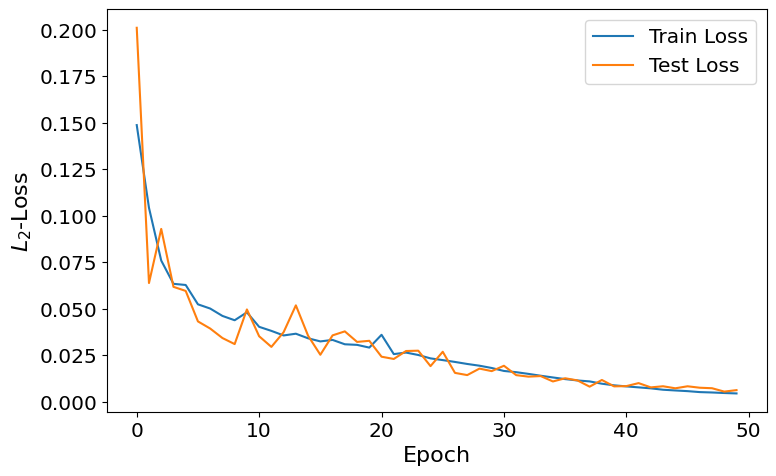

In [31]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

plot_losses(train_losses, test_losses)

In [32]:
train_idx = np.random.randint(0, (1-test_ratio)*N_total)
test_idx = np.random.randint(0, test_ratio*N_total)

In [33]:
train_Ran = train_R_anode[train_idx]
train_Rca = train_R_cathode[train_idx]
test_Ran = test_R_anode[test_idx]
test_Rca = test_R_cathode[test_idx]

In [34]:
train_Ran, test_Ran, train_Rca, test_Rca = rescale_parameters(train_Ran, test_Ran, train_Rca, test_Rca, "R_n|Negative particle radius [m]", "R_p|Positive particle radius [m]", log_scale=True)

In [35]:
c_train_true = train_cn_anode[train_idx]
c_train_pred = model.apply(params,X_train[train_idx][None,...], train_D_anode[train_idx][None,...], train_R_anode[train_idx][None,...])

c_test_true = test_cn_anode[test_idx]
c_test_pred = model.apply(params,X_test[test_idx][None,...], test_D_anode[test_idx][None,...], test_R_anode[test_idx][None,...])


# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_true_reshaped = c_train_true  # already (20,75)
c_test_true_reshaped = c_test_true   # already (20,75)
c_train_pred_reshaped = remove_padding(c_train_pred, padding_r, padding_t)
c_test_pred_reshaped = remove_padding(c_test_pred, padding_r, padding_t)

In [36]:
c_train_pred_reshaped = jnp.squeeze(c_train_pred_reshaped, axis=(0,-1))  # (20,75)
c_test_pred_reshaped = jnp.squeeze(c_test_pred_reshaped, axis=(0,-1))  # (20,75)

In [37]:
c_max = params_bat["Maximum concentration in negative electrode [mol.m-3]"]

In [38]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max


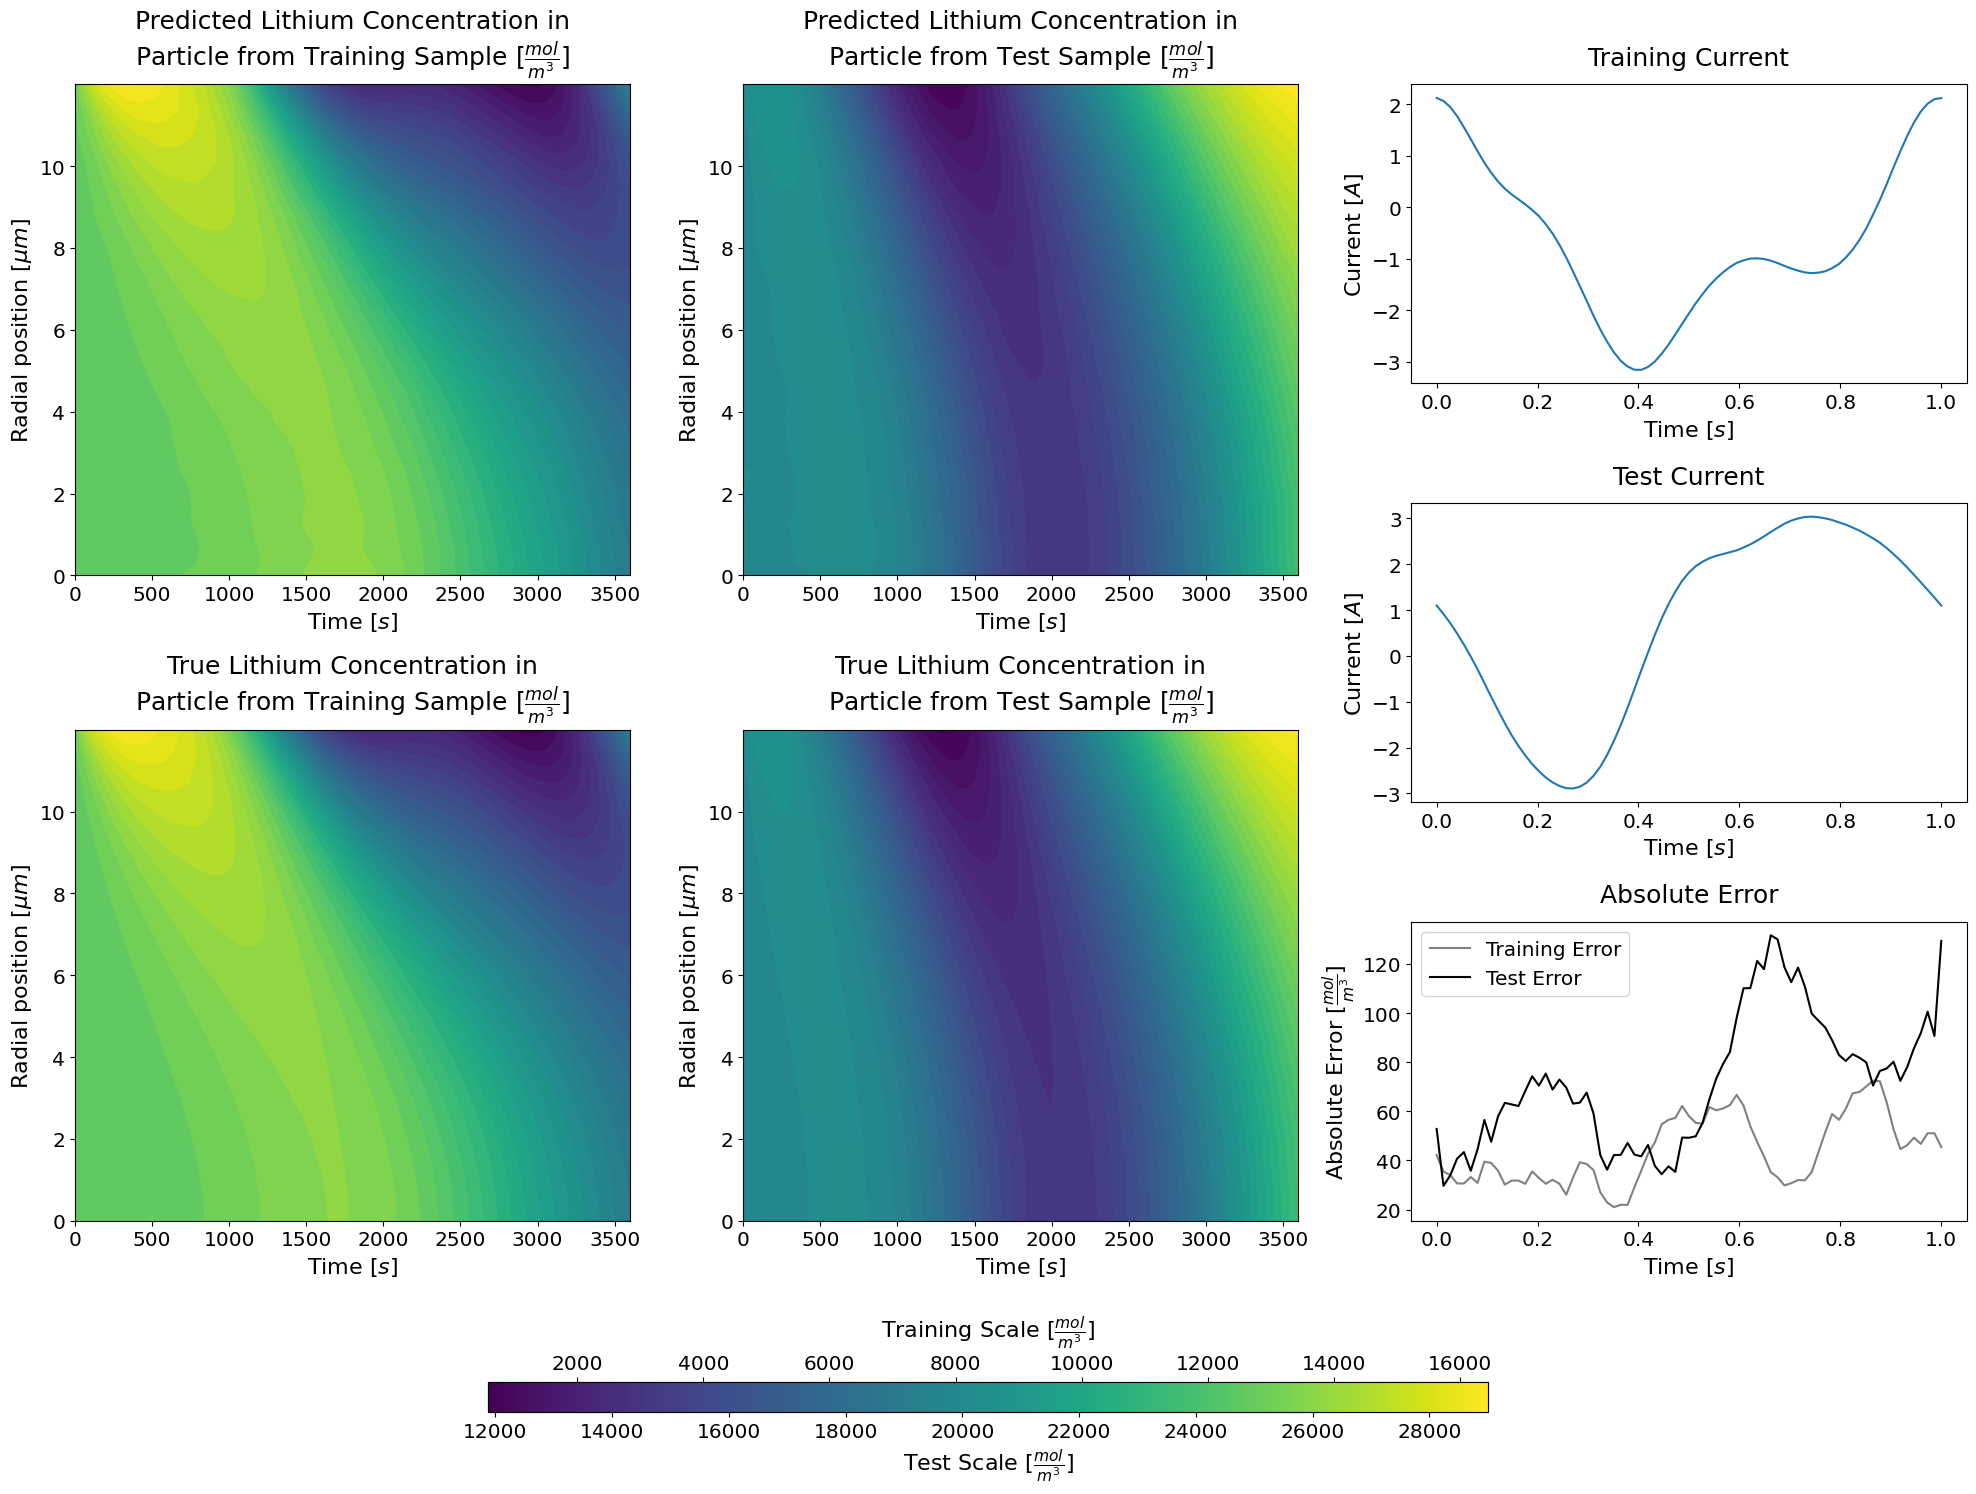

In [39]:
fig, axs = create_plot_FNO_results(c_train_pred_scaled, c_train_true_scaled, c_test_pred_scaled, c_test_true_scaled,
                     train_I[train_idx], test_I[test_idx], t_max, train_Ran)

plt.show()

In [40]:
filename = functions.save_model_params(params, directory = "../trained_models/cape_fno2/", family = family, parameter_name = parameter_name, N_total = N_total)

Saved model parameters to ../trained_models/cape_fno2/anode_Prada2013_GRF_33011_2025-07-02_01-21-20.msgpack


In [41]:
modelid = f"{parameter_name}_{family}_{N_total}_model"

In [42]:
import gc
# del model
# del params
del X_train, Y_train, X_test, Y_test

#jax.clear_compilation_cache()
gc.collect()


8896

In [43]:
X_train, Y_train = preprocess_data(train_I, train_c0_cathode, train_cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)
X_test, Y_test = preprocess_data(test_I, test_c0_cathode, test_cn_cathode, num_samples_I, num_samples_c0, padding_r, padding_t)

In [44]:
model = CAPE_FNO2(k_modes=k_modes, input_channels= input_channels, fno_depth=fno_depth, cape_hidden_size = cape_hidden_size, hidden_channels=hidden_channels, output_channels=output_channels)

# Initialize parameters
init_key = jax.random.PRNGKey(42)
dummy_D = jax.random.normal(init_key, (1,1))
dummy_R = jax.random.normal(init_key, (1,1))
params = model.init(init_key, X_train[:1,...], dummy_D, dummy_R)

# Forward pass
out = model.apply(params, X_train[:1,...], dummy_D, dummy_R)

In [45]:
pbar = trange(num_epochs, desc="Training")

train_losses = []
test_losses = []

for epoch in pbar:

    total_train_loss = 0.0
    count = 0

    for X_batch, D_batch, R_batch, Y_batch in data_loader_pe(X_train, train_D_cathode, train_R_cathode, Y_train, batch_size):
        params, opt_state, loss_value = train_step(params, opt_state, jnp.array(X_batch), jnp.array(D_batch), jnp.array(R_batch), jnp.array(Y_batch))
        total_train_loss += loss_value
        count += 1

    total_test_loss = 0.0
    count2 = 0

    for X_batch,D_batch, R_batch, Y_batch in data_loader_pe(X_test,test_D_cathode,test_R_cathode, Y_test, 200):
        loss_value = loss_fn(params, jnp.array(X_batch), jnp.array(D_batch), jnp.array(R_batch), jnp.array(Y_batch))
        total_test_loss += loss_value
        count2 += 1


    # train_losses.append(total_train_loss)
    # test_losses.append(total_test_loss)

    avg_train_loss = total_train_loss / count
    avg_test_loss = total_test_loss / count2

    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)

    desc_str = f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}"
    pbar.set_description_str(desc_str)

Epoch 50/50 | Train Loss: 0.0061 | Test Loss: 0.0064: 100%|██████████| 50/50 [27:24<00:00, 32.90s/it]


In [46]:
filename = functions.save_model_params(params, directory = "../trained_models/cape_fno2", prefix = "cathode", family = family, parameter_name = parameter_name, N_total = N_total)

Saved model parameters to ../trained_models/cape_fno2/cathode_Prada2013_GRF_33011_2025-07-02_01-48-46.msgpack


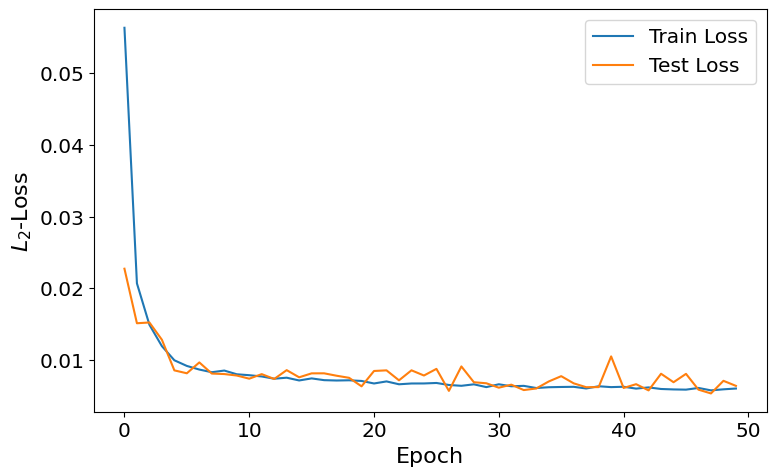

In [47]:
# Set global font sizes
plt.rcParams.update({
    'font.size': 14.5,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14.5,
    'ytick.labelsize': 14.5,
    'legend.fontsize': 14.5,
    'figure.titlesize': 20
})

plot_losses(train_losses, test_losses)

In [48]:
c_train_true = train_cn_cathode[train_idx]
c_train_pred = model.apply(params,X_train[train_idx][None,...], train_D_cathode[train_idx][None,...], train_R_cathode[train_idx][None,...])

c_test_true = test_cn_cathode[test_idx]
c_test_pred = model.apply(params,X_test[test_idx][None,...], test_D_cathode[test_idx][None,...], test_R_cathode[test_idx][None,...])


# Predicted concentration has shape (1,24,85,1)
# Slice out the original domain: [2:22, 5:80]
c_train_true_reshaped = c_train_true  # already (20,75)
c_test_true_reshaped = c_test_true   # already (20,75)
c_train_pred_reshaped = remove_padding(c_train_pred, padding_r, padding_t)
c_test_pred_reshaped = remove_padding(c_test_pred, padding_r, padding_t)

In [49]:
c_train_pred_reshaped = jnp.squeeze(c_train_pred_reshaped, axis=(0,-1))  # (20,75)
c_test_pred_reshaped = jnp.squeeze(c_test_pred_reshaped, axis=(0,-1))  # (20,75)

In [50]:
c_max = params_bat["Maximum concentration in positive electrode [mol.m-3]"]

In [51]:
c_train_pred_scaled = c_train_pred_reshaped * c_max
c_test_pred_scaled = c_test_pred_reshaped * c_max

c_test_true_scaled = c_test_true * c_max
c_train_true_scaled = c_train_true * c_max

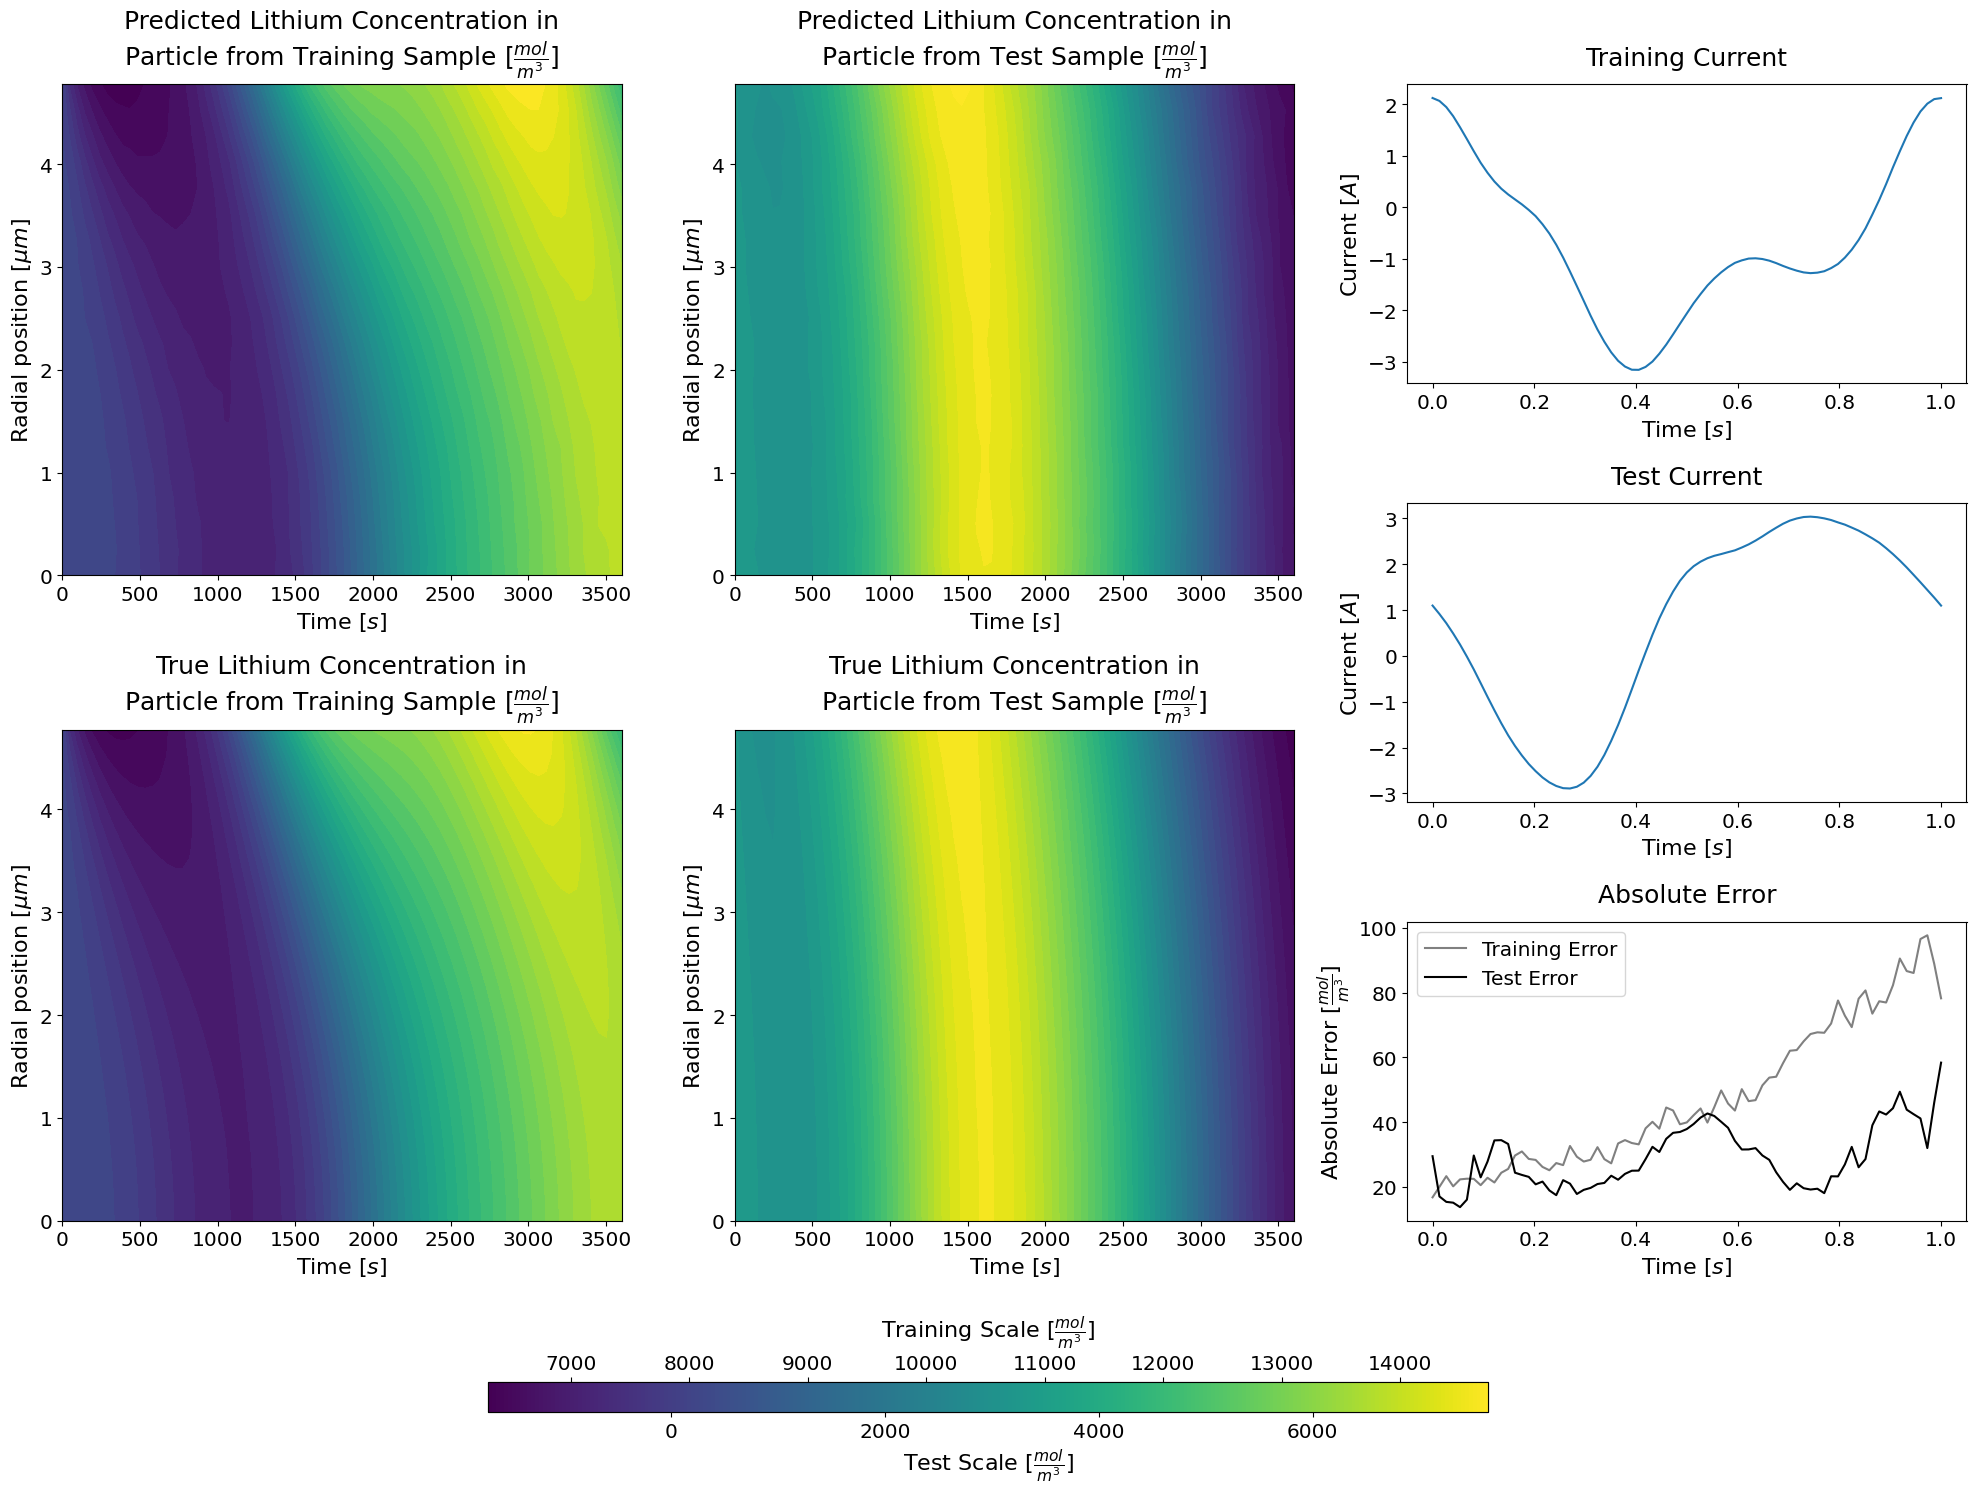

In [52]:
fig, axs = create_plot_FNO_results(c_train_pred_scaled, c_train_true_scaled, c_test_pred_scaled, c_test_true_scaled,
                     train_I[train_idx], test_I[test_idx], t_max, train_Rca)

plt.show()